In [2]:
# =========================================================================
# 설비 이상감지 + 원인분류 실습 
#
# 분석 프로세스
# 1) 정상/이상 설비 데이터 생성
# 2) 주요 영향인자 선정
# 3) 설비 특성 기반 파생변수(치명인자) 생성
# 4) 최적 Indicator 선정
# 5) 치명인자 관계 영향도 그래프 확인
# 6) 머신러닝 기반의 Warning / Critical Threshold 기준 정의
# 7) 이상 원인 진단 분류
# 8) 신규 데이터 이상감지 및 원인분류 테스트
# 9) 도메인 기반 결과 해석
# =========================================================================


In [3]:
! pip install networkx

In [4]:
# -------------------------------------------------
# 1. 기본 라이브러리 Import
# -------------------------------------------------

import numpy as np                           # 수치 계산을 위한 라이브러리
import pandas as pd                          # 표 형태 데이터 처리를 위한 라이브러리
import matplotlib.pyplot as plt              # 그래프 시각화 처리를 위한 라이브러리
import seaborn as sns                        # 그래프 시각화                       
import networkx as nx                        # 변수 간 관계 그래프를 그리기 위한 라이브러리

from sklearn.model_selection import train_test_split                # 학습/검증 데이터 분리 함수
from sklearn.preprocessing import StandardScaler                    # 변수 스케일 표준화를 위한 클래스
from sklearn.ensemble import RandomForestClassifier                 # 원인분류 모델로 사용할 랜덤포레스트
from sklearn.ensemble import IsolationForest                        # 비지도 이상감지 모델
from sklearn.metrics import classification_report                   # 분류 성능 리포트 출력
from sklearn.metrics import confusion_matrix                        # 혼동행렬 계산 함수
from sklearn.metrics import roc_curve                               # ROC 기반 threshold 탐색
from sklearn.metrics import roc_auc_score                           # 이상 감지 성능 AUC 계산 함수
from sklearn.inspection import permutation_importance               # 변수 중요도 검증 함수
from sklearn.feature_selection import mutual_info_classif           # 변수와 이상 여부 간 비선형 관련성 계산  

import warnings                                                     # 불필요한 경고 제거
warnings.filterwarnings("ignore")

np.random.seed(42)

In [5]:
# -------------------------------------------------
# 2. 설비 데이터 생성 함수
# -------------------------------------------------

def generate_machine_data(n_normal=5000, n_abnormal_each=1000):
    # 정상 데이터 5000개 생성
    # 고장 유형별로 이상 데이터를 1000개씩 생성

    rows= []     # 생성된 데이터를 저장할 빈 리스트 생성
    fault_type = ["normal", "bearing_wear", "lubrication_fault", "hydraulic_leak"]
    '''
    1. bearing_wear
    -원인 : 부적절한 윤활, 먼지, 금속입자 등 오염물질 유입, 과도한 하중, 부식
    -증상 : 기계 작동 시, 평소와 다른 소음 발생, 과도한 진동, 부품의 발열 및 효율 저하

    2, lubrication_fault
    -원인 : 누유, 씰 또는 오링의 노상 마모 및 파손으로 인해 오일이 외부로 새어 나가는 경우 및 또는 이물질 혼입
    -증상 : 마찰에 의한 이상 소음 및 진동, 발열, 마모 및 분진 발생

    3. hydraulic_leak
    -원인 : 마모 및 노후화 - 고압의 기름을 전달하는 호스가 찢어지거나 연결 부위의 고무 씰이 닳았을 때 발생
    -증상 : 진동 및 과열, 실린더/프레스 등 성능 저하, 모터 과부하, 설비 소음 및 진동 발생, 발열 발생
    '''

    # 정상과 고장 유형의 이름 데이터 범위 정의
    for fault in fault_type:
        # 정상과 각 고장 유형에 대해 반복 수행
        if fault == "normal":
            n = n_normal                     # 정상 데이터 개수
        else:
            n = n_abnormal_each              # 이상 데이터 개수

        for i in range(n):   # 각 센서를 하나씩 생성
            rpm = np.random.normal(1500, 40)
            # 설비 회전수 생성 : 정상 기준 평균 1500 rpm, 표준편차 40

            load = np.random.normal(65, 8)
            # 설비 부하율 생성 : 정상 기준 평균 65, 표준편차 8

            pressure = np.random.normal(120, 5)
            # 유압 압력 생성 : 정상 기준 평균 120 bar, 표준편차 5

            temp = np.random.normal(55, 3)
            # 베어링 또는 구동부 온도 생성 : 정상 기준 평균 55도, 표준편차 3

            vibration = np.random.normal(1.2, 0.2)
            # 진동 RMS 생성 : 정상 기준 평균 1.2, 표준편차 0.2

            current = np.random.normal(22, 2)
            # 모터 전류 생성 : 정상 기준 평균 22A, 표준편차 2

            oil_viscosity = np.random.normal(42, 3)
            # 윤활유 점도 생성 : 정상 기준 평균 42 cSt, 표준편차 3

            flow_rate = np.random.normal(80, 5)
            # 유량 생성 : 정상 기준 평균 80 L/min, 표준편차 5

            noise_1 = np.random.normal(0, 1)
            # 의미 없는 랜덤 변수 1 생성

            noise_2 = np.random.normal(10, 5)
            # 의미 없는 랜덤 변수 2 생성

            noise_3 = np.random.normal(0, 100)
            # 의미 없는 랜덤 변수 3 생성

            if fault == "bearing_wear":
                # 베어링 마모 고장 조건
                vibration += np.random.normal(1.2, 0.25)  # 베어링 마모시 진동이 증가함

                temp += np.random.normal(8, 2)            # 베어링 마모시 마찰열로 온도가 증가함

                current += np.random.normal(3,1)          # 마찰 증가로 모토 전류가 증가함

            elif fault == "lubrication_fault":
                # 윤활 불량 고장 조건
                oil_viscosity -= np.random.normal(12, 2)    # 윤활유 점도가 낮아짐

                temp += np.random.normal(10, 2)             # 윤활 불량으로 온도가 증가함

                vibration += np.random.normal(0.7, 0.2)     # 윤활 불량으로 진동이 증가함

                current += np.random.normal(2, 0.8)         # 마찰 증가로 모토 전류가 증가함

            elif fault == "hydraulic_leak":
                # 유압 누설 고장 조건
                pressure -= np.random.normal(25, 4)         # 누설로 인해 압력이 감소함

                flow_rate -= np.random.normal(18, 4)        # 누설 또는 효율 저하로 유량이 감소함

                current += np.random.normal(1.5, 0.6)       # 보상 운전으로 전류가 증가함

                load -= np.random.normal(5, 2)              # 유압 효율 저하로 실제 부하 전달력이 낮아짐


            if fault == "normal":
                is_abnormal = 0            # 정상 데이터는 0으로 표시

            else:
                is_abnormal = 1            # 이상 데이터는 1로 표시


            rows.append([                  # 하나의 샘플을 리스트에 추가
                rpm,
                load,
                pressure,
                temp,
                vibration,
                current,
                oil_viscosity,
                flow_rate,
                noise_1,
                noise_2,
                noise_3,
                is_abnormal,
                fault
            ])

    columns = [     # 데이터프레임 컬럼 이름 정의
        "rpm",
        "load",
        "pressure",
        "temp",
        "vibration",
        "current",
        "oil_viscosity",
        "flow_rate",
        "noise_1",
        "noise_2",
        "noise_3",
        "is_abnormal",
        "fault_type"
    ]

    df = pd.DataFrame(rows, columns=columns)    # 리스트 데이터를 DataFrame으로 변환

    return df           


In [6]:
# -------------------------------------------------
# 3. 데이터 생성
# -------------------------------------------------

df = generate_machine_data()   # 설비 정상/이상 데이터 생성

df.head()    # 상위 데이터 5개 확인

,rpm,load,pressure,temp,vibration,current,oil_viscosity,flow_rate,noise_1,noise_2,noise_3,is_abnormal,fault_type
0,1519.868566,63.893886,123.238443,59.569090,1.153169,21.531726,46.737638,83.837174,-0.469474,12.712800,-46.341769,0,normal
1,1481.370810,66.935698,110.433599,49.825247,1.087542,19.974338,42.942742,75.459880,-1.412304,17.328244,-22.577630,0,normal
2,1502.701128,53.602015,117.278086,55.332768,0.969801,22.751396,40.198084,78.541531,-0.601707,19.261391,-1.349722,0,normal
3,1457.691563,71.580359,113.895782,55.626591,0.808066,19.343628,42.590584,83.692333,0.171368,9.421759,-30.110370,0,normal
4,1440.859120,59.241246,117.696806,58.171367,1.268724,18.473920,42.972252,78.074589,-0.676922,13.058381,103.099952,0,normal


In [7]:
# 고장 유형별 데이터 개수 확인
df["fault_type"].value_counts()

fault_type
normal               5000
bearing_wear         1000
lubrication_fault    1000
hydraulic_leak       1000
Name: count, dtype: int64

In [10]:
# -------------------------------------------------
# 4. 주요 영향인자 선정 
# -------------------------------------------------

# row 데이터 변수 목록 정의
sensor_cols =[
    "rpm",
    "load",
    "pressure",
    "temp",
    "vibration",
    "current",
    "oil_viscosity",
    "flow_rate",
    "noise_1",
    "noise_2",
    "noise_3"
]

X_sensor = df[sensor_cols]   # 센서 변수만 입력 데이터로 선택

y_abnormal = df["is_abnormal"]    # 정상/이상 라벨 선택


## 1) 상관계수, 2) mutual information, 3) 랜덤포레스트 3가지의 중요도로 확인

# 1) x, y 간의 상관관계 판단
corr_result = df[sensor_cols + ["is_abnormal"]].corr()["is_abnormal"].abs().sort_values(ascending=False)
# 각 센서 변수와 이상 여부 간 상관계수 절댓값 계산 <-- 고장과의 선형관계 확인(영향도)   예) 온도 상승 --> 고장

# 2) x, y 간의 비선형 관계 판단
mi_scores = mutual_info_classif(X_sensor, y_abnormal, random_state=42)
# 각 센서 변수와 이상 여부 간 비선형 정보량 계산
# 비선형을 확인 이유는 고장은 상승, 급감소의 상태도 있기때문에 비선형으로도 확인 필요)
# 예) 온도 상승 --> 고장 / 온도 급감소 --> 고장

mi_result = pd.Series(mi_scores, index=sensor_cols).sort_values(ascending=False)
# 결과를 보기 좋게 series 형태로 변환

# 3) rf 모델 예측 기여도 판단
rf_for_importance = RandomForestClassifier(n_estimators=300, random_state=42)   # 변수 중요도 계산을 위한 RF 모델 생성

rf_for_importance.fit(X_sensor, y_abnormal)    # 랜던포레스트 기반 row 센서 정상/이상 분류 모델 학습

rf_importance = pd.Series(rf_for_importance.feature_importances_, index=sensor_cols).sort_values(ascending=False)
# 랜덤포레스 모델 기반 변수 중요도 계산  <-- 잘 예측했다면 변수들은 중요도가 높다고 판단

# 상관계수, mutual information, 랜던포레스트 중요도 결과를 dataframe으로 통합
importance_df = pd.DataFrame({        
    "corr_abs": corr_result.drop("is_abnormal"),
    "mutual_info": mi_result,
    "rf_importance": rf_importance
})

# 세가지 기준의 순위를 합산하여 종합 점수 계산
importance_df["total_score"] = (
    importance_df["corr_abs"].rank(ascending=True) +
    importance_df["mutual_info"].rank(ascending=True) +
    importance_df["rf_importance"].rank(ascending=True)
)

importance_df = importance_df.sort_values("total_score", ascending=False)   # 종합 점수가 높은 순서대로 정렬

importance_df  

,corr_abs,mutual_info,rf_importance,total_score
vibration,0.624287,0.266702,0.341067,33.0
temp,0.574843,0.232467,0.187249,29.0
pressure,0.407246,0.126825,0.217685,27.0
current,0.459421,0.123947,0.041157,23.0
flow_rate,0.371761,0.115161,0.117143,21.0
oil_viscosity,0.384970,0.106068,0.077990,20.0
load,0.090791,0.006220,0.004916,15.0
noise_3,0.007961,0.005287,0.003418,11.0
noise_2,0.013978,0.000000,0.003096,8.0
rpm,0.000074,0.000000,0.003298,6.0


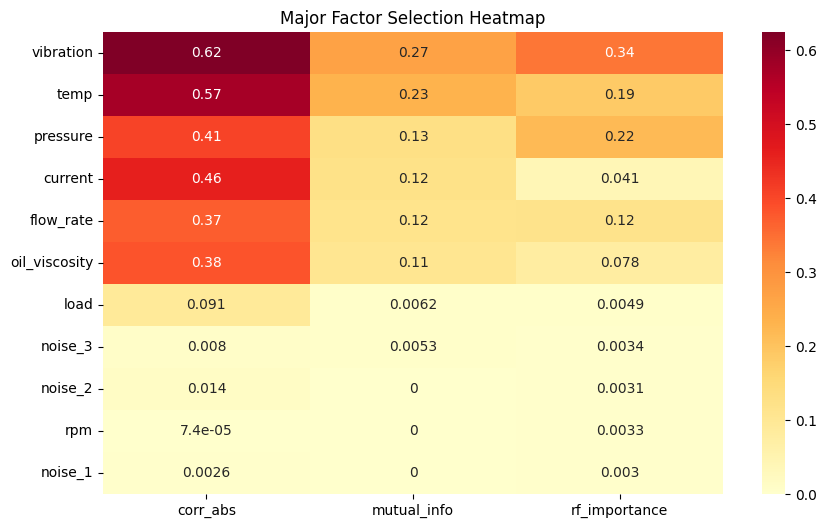

In [11]:
# -------------------------------------------------
# 7. 주요 영향인자 히트맵 시각화 
# -------------------------------------------------
plt.figure(figsize=(10,6))

# 영향 인자 점수를 히트맵으로 표현
sns.heatmap(
    importance_df[["corr_abs", "mutual_info", "rf_importance"]],
    annot=True,
    cmap="YlOrRd"
)
plt.title("Major Factor Selection Heatmap")
plt.show()



In [ ]:
# ----------------------------------------------------
# 6. 설비 특성 기반의 파생변수(치명인자) 생성 (row 기준) 
# ----------------------------------------------------


